In [1]:
using ScQubitsMimic
using CairoMakie

_scqubitsmimic_example_dir = normpath(joinpath(dirname(pathof(ScQubitsMimic)), "..", "examples"))
if !isdefined(Main, :ScQubitsMimicExampleMakie)
    include(joinpath(_scqubitsmimic_example_dir, "makie_fontsetup.jl"))
end
ScQubitsMimicExampleMakie.setup_makie_font!()


"Apple SD Gothic Neo"


## 예제 1: TunableTransmon-TunableCoupler-TunableTransmon

1. Yan, F. et al. Tunable Coupling Scheme for Implementing High-Fidelity Two-Qubit Gates. Phys. Rev. Applied 10, 054062 (2018).

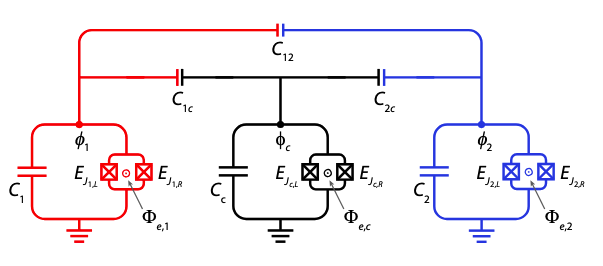

In [2]:


tcap_coupled_tmon = """
branches:
  - [JJ, 0, 1, EJ=12.0, EC=10.0]
  - [JJ, 1, 0, EJ=12.0, EC=10.0]
  - [C, 1, 0, EC=0.2]
  - [C, 1, 2, EC=5.0]
  - [JJ, 0, 2, EJ=24.0, EC=10.0]
  - [JJ, 2, 0, EJ=24.0, EC=10.0]
  - [C, 2, 0, EC=0.1]
  - [C, 2, 3, EC=5.0]
  - [JJ, 0, 3, EJ=12.0, EC=10.0]
  - [JJ, 3, 0, EJ=12.0, EC=10.0]
  - [C, 3, 0, EC=0.2]
"""
circ1 = Circuit(tcap_coupled_tmon; ncut=4)  # keep the grounded demo executable


Circuit(SymbolicCircuit(CircuitGraph(Branch[Branch(JJ, 0→1, EJ=12.0, EC=10.0), Branch(JJ, 1→0, EJ=12.0, EC=10.0), Branch(C, 1→0, EC=0.2), Branch(C, 1→2, EC=5.0), Branch(JJ, 0→2, EJ=24.0, EC=10.0), Branch(JJ, 2→0, EJ=24.0, EC=10.0), Branch(C, 2→0, EC=0.1), Branch(C, 2→3, EC=5.0), Branch(JJ, 0→3, EJ=12.0, EC=10.0), Branch(JJ, 3→0, EJ=12.0, EC=10.0), Branch(C, 3→0, EC=0.2)], 3, true), [3, 4, 8], [1, 2, 5, 6, 7, 9, 10, 11], [[(1, 1), (3, 1)], [(2, 1), (3, -1)], [(5, 1), (3, 1), (4, -1)], [(6, 1), (4, 1), (3, -1)], [(7, 1), (4, 1), (3, -1)], [(9, 1), (3, 1), (4, -1), (8, -1)], [(10, 1), (8, 1), (4, 1), (3, -1)], [(11, 1), (8, 1), (4, 1), (3, -1)]], Symbolics.Num[φ₁, φ₂, φ₃], Symbolics.Num[φ̇₁, φ̇₂, φ̇₃], Symbolics.Num[0.675 -0.025 0; -0.025 1.325 -0.025; 0 -0.025 0.675], Symbolics.Num[0 0 0; 0 0 0; 0 0 0], -24.0(cos(-Φext₄ - φ₂) + cos(-Φext₃ + φ₂)) - 12.0(cos(-Φext₅ + φ₃) + cos(-Φext₂ - φ₁) + cos(-Φext₆ - φ₃) + cos(-Φext₁ + φ₁)) + 2.9650364150014252(n₁^2 + n₃^2) + 0.11196641007697691n₁*n₂ +

In [3]:
println("Grounded custom circuit constructed.")
println("Mode categories: ", circ1.var_categories)
println("External flux variables: ", external_fluxes(circ1))
println("First 4 eigenvalues: ", eigenvals(circ1; evals_count=4))

Grounded custom circuit constructed.
Mode categories: VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[])
External flux variables: Symbolics.Num[Φext₁, Φext₂, Φext₃, Φext₄, Φext₅, Φext₆]
First 4 eigenvalues: [-78.46448005194475, -67.36576261506029, -67.33041796145622, -66.27998085601128]
